<a href="https://colab.research.google.com/github/Trishul32/ML_LAB/blob/main/Lab_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas scikit-learn numpy

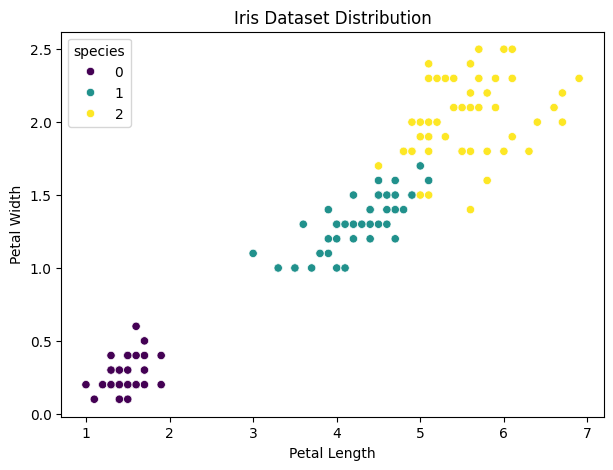

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



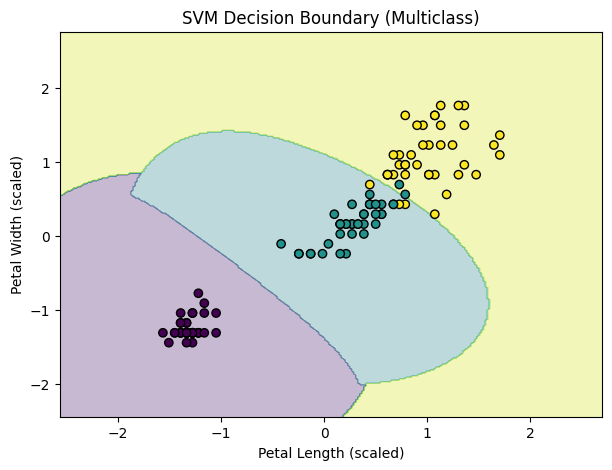

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
iris = load_iris()

# Create dataframe
data = pd.DataFrame(iris.data, columns=iris.feature_names)
data['species'] = iris.target

# Use only 2 features for visualization
X = data[['petal length (cm)', 'petal width (cm)']]
y = data['species']

# ---------------------------
# GRAPH 1: Feature Scatter Plot
# ---------------------------
plt.figure(figsize=(7,5))
sns.scatterplot(
    x=X['petal length (cm)'],
    y=X['petal width (cm)'],
    hue=y,
    palette='viridis'
)

plt.title("Iris Dataset Distribution")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Feature scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM model
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ---------------------------
# GRAPH 2: SVM Decision Boundary
# ---------------------------

# Create mesh grid
x_min, x_max = X_train[:,0].min()-1, X_train[:,0].max()+1
y_min, y_max = X_train[:,1].min()-1, X_train[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))

plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

plt.scatter(
    X_train[:,0],
    X_train[:,1],
    c=y_train,
    cmap='viridis',
    edgecolors='k'
)

plt.title("SVM Decision Boundary (Multiclass)")
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.show()

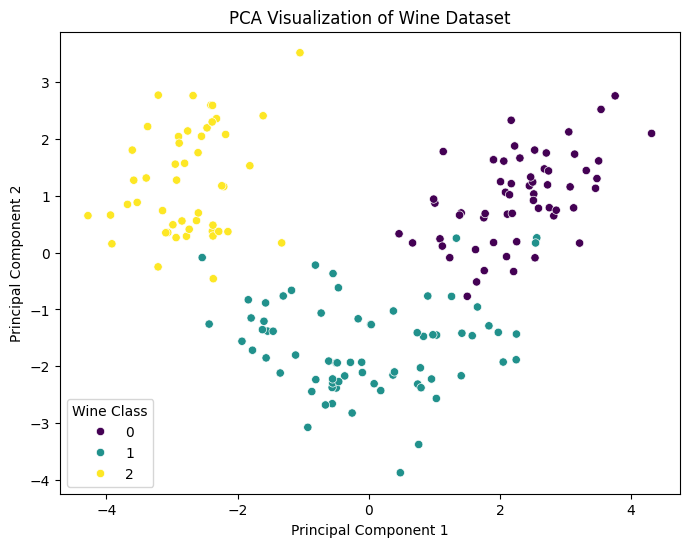

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Wine dataset
wine = load_wine()

# Create DataFrame
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA (reduce to 2 dimensions)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create dataframe for visualization
pca_df = pd.DataFrame(
    data=X_pca,
    columns=['Principal Component 1', 'Principal Component 2']
)
pca_df['Class'] = y

# -----------------------------
# Graph: PCA Visualization
# -----------------------------
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Principal Component 1',
    y='Principal Component 2',
    hue='Class',
    palette='viridis',
    data=pca_df
)

plt.title("PCA Visualization of Wine Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Wine Class")

plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# Split the scaled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Train an SVM classifier
svm_model = SVC(kernel='linear', random_state=42) # Using a linear kernel for simplicity
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Print the classification report
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87        75
           1       0.89      0.84      0.86        75

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.87      0.87      0.87       150



Accuracy: 0.9733333333333334

Classification Report:

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        75
           1       1.00      0.95      0.97        75

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



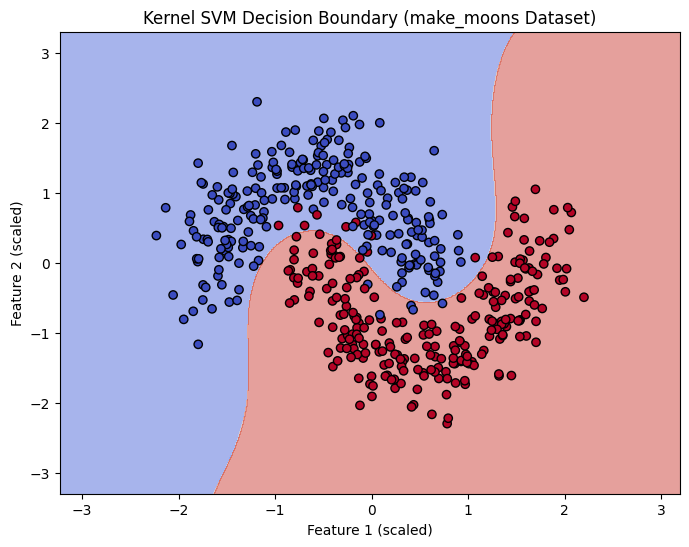

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# Load make_moons synthetic dataset
# -----------------------------
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

# -----------------------------
# Train Kernel SVM (RBF kernel)
# -----------------------------
model = SVC(kernel='rbf', C=1.0, gamma='scale')
model.fit(X_train, y_train)

# Predictions and Evaluation
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -----------------------------
# Graph: SVM Decision Boundary
# -----------------------------
# Grid for plotting
x_min, x_max = X_scaled[:,0].min() - 1, X_scaled[:,0].max() + 1
y_min, y_max = X_scaled[:,1].min() - 1, X_scaled[:,1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.01),
    np.arange(y_min, y_max, 0.01)
)

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.5, cmap='coolwarm')

# Scatter original points
plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=y,
    cmap='coolwarm',
    edgecolors='k'
)

plt.title("Kernel SVM Decision Boundary (make_moons Dataset)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.show()